In [1]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report, precision_score, f1_score

In [2]:
# Download NLTK data (run this once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# Load the dataset
df = pd.read_csv('data.csv')
df.head(10)

,email,label
0,we know you would love to see all these wonder...,1
1,start date hourahead hour no ancillari schedul...,0
2,the deal are all in meter is on deal and meter...,0
3,per your phone messag the gri flag ha been cha...,0
4,o italiano marco carola e gaetano parisio enca...,1
5,just in case you want to have around forward b...,0
6,urgent safeharbor depart notic ebay fraud medi...,1
7,our chernist site help you bank a lot on quali...,1
8,our autom system is easi to use and you will l...,1
9,there is thi free date site fill with a bunch ...,1


In [4]:
# Preprocessing Function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization and Stemming
    lemmatizer = WordNetLemmatizer()
    stemmer = PorterStemmer()
    
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatization
    tokens = [stemmer.stem(word) for word in tokens]  # Stemming
    
    # Join tokens back into a string
    processed_text = ' '.join(tokens)
    return processed_text

# Apply preprocessing to the 'email' column
df['processed_email'] = df['email'].apply(preprocess_text)

In [5]:
# Feature Extraction: Using Bag of Words (TF-IDF) for email content
vectorizer = TfidfVectorizer(max_features=5000)  # Bag of words with max 5000 features
X = vectorizer.fit_transform(df['processed_email']).toarray()  # Transform processed emails into feature vectors
y = df['label']  # Labels: 0 or 1

In [6]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Model: Logistic Regression
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [8]:
# Predictions
y_pred = log_reg_model.predict(X_test)

In [9]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9832


In [10]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[3059   82]
 [  23 3098]]


In [11]:
# Classification Report (gives precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3141
           1       0.97      0.99      0.98      3121

    accuracy                           0.98      6262
   macro avg       0.98      0.98      0.98      6262
weighted avg       0.98      0.98      0.98      6262



In [12]:
# Compute Precision, Recall, F1-score separately
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"\nPrecision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")


Precision: 0.9742
F1 Score: 0.9833


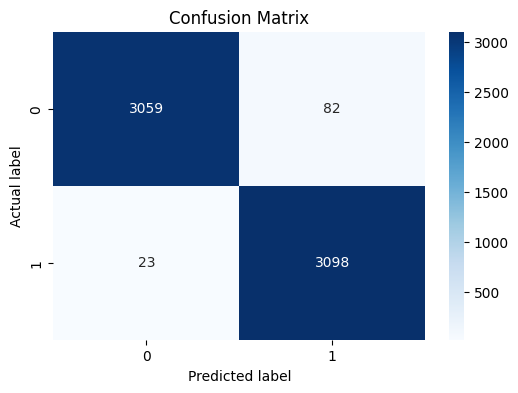

In [13]:
# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [14]:
# ROC Curve
y_pred_prob = log_reg_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

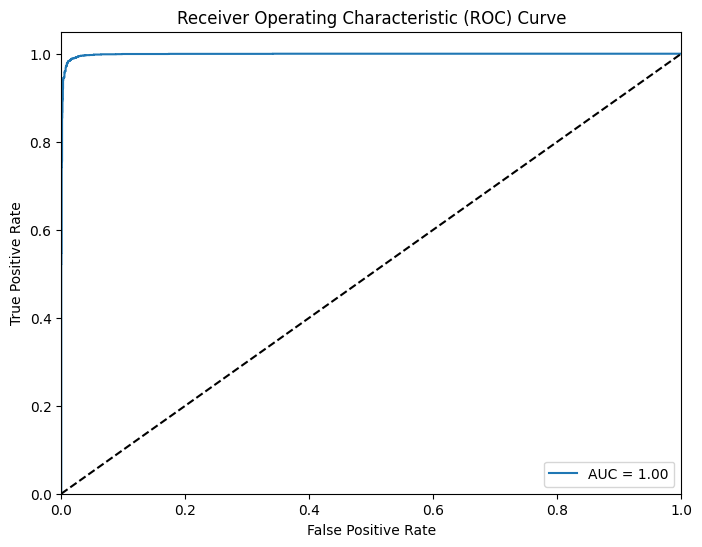

In [15]:
# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()